# 📱 Análise de Comportamento de Uso de Smartphones

Camada narrativa do projeto: importa as funções dos módulos em `src/` e demonstra, passo a passo, os resultados com gráficos. Toda a lógica vive nos scripts — aqui contamos a *história* dos dados.

**Roteiro:** carregamento → descritiva → EDA → inferência → modelagem (regressão, classificação, K-Means).

## 0. Setup

In [1]:
import sys
from pathlib import Path

_dir = Path.cwd()
while not (_dir / 'src').exists() and _dir != _dir.parent:
    _dir = _dir.parent
if str(_dir) not in sys.path:
    sys.path.insert(0, str(_dir))
print('Raiz do projeto:', _dir)

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
pd.set_option('display.width', 180)

Raiz do projeto: C:\Users\costd\OneDrive\Documentos\universidade dos dados\mobile_device


## 1. Carregamento e limpeza
Padronizamos os nomes das colunas e criamos variáveis derivadas (consumo por app, bateria por hora de tela, faixa etária).

In [2]:
from src.data_loader import load_raw_data
from src.preprocessing import clean_data

df = clean_data(load_raw_data())
print(f'\nBase: {df.shape[0]} usuários x {df.shape[1]} colunas')
df.head()

[data_loader] 700 registros carregados de user_behavior_dataset.csv.
[preprocessing] Nulos: 0 | duplicatas removidas: 0
[preprocessing] Base analítica final: 700 linhas × 16 colunas.

Base: 700 usuários x 16 colunas


,user_id,device_model,os,app_usage_min,screen_on_hours,battery_drain_mah,num_apps,data_usage_mb,age,gender,behavior_class,data_por_app,bateria_por_hora_tela,uso_por_hora_tela,faixa_etaria,behavior_label
0,1,Google Pixel 5,Android,393,6.40,1872,67,1122,40,Male,4,16.75,292.50,61.41,36-45,4 - Pesado
1,2,OnePlus 9,Android,268,4.70,1331,42,944,47,Female,3,22.48,283.19,57.02,46-59,3 - Moderado
2,3,Xiaomi Mi 11,Android,154,4.00,761,32,322,42,Male,2,10.06,190.25,38.50,36-45,2 - Leve
3,4,Google Pixel 5,Android,239,4.80,1676,56,871,20,Male,3,15.55,349.17,49.79,18-25,3 - Moderado
4,5,iPhone 12,iOS,187,4.30,1367,58,988,31,Female,3,17.03,317.91,43.49,26-35,3 - Moderado


## 2. Estatística descritiva

In [3]:
from src.descriptive_stats import tabela_descritiva, teste_normalidade
tabela_descritiva(df)

,n,media,mediana,moda,desvio_padrao,coef_variacao_%,minimo,q1,q3,maximo,iqr,assimetria,curtose
variavel,,,,,,,,,,,,,
app_usage_min,700,271.13,227.50,64.00,177.20,65.36,30.00,113.25,434.25,598.00,321.00,0.37,-1.26
screen_on_hours,700,5.27,4.90,1.60,3.07,58.20,1.00,2.50,7.40,12.00,4.90,0.46,-0.82
battery_drain_mah,700,"1,525.16","1,502.50",490.00,819.14,53.71,302.00,722.25,"2,229.50","2,993.00","1,507.25",0.13,-1.27
num_apps,700,50.68,49.00,10.00,26.94,53.16,10.00,26.00,74.00,99.00,48.00,0.11,-1.25
data_usage_mb,700,929.74,823.50,122.00,640.45,68.88,102.00,373.00,"1,341.00","2,497.00",968.00,0.70,-0.47
age,700,38.48,38.00,34.00,12.01,31.22,18.00,28.00,49.00,59.00,21.00,0.03,-1.23


In [4]:
teste_normalidade(df)

,estatistica,p_valor,normal_(alpha=0.05)
variavel,,,
app_usage_min,816.23,0.00,False
screen_on_hours,84.16,0.00,False
battery_drain_mah,945.06,0.00,False
num_apps,766.27,0.00,False
data_usage_mb,58.15,0.00,False
age,636.66,0.00,False


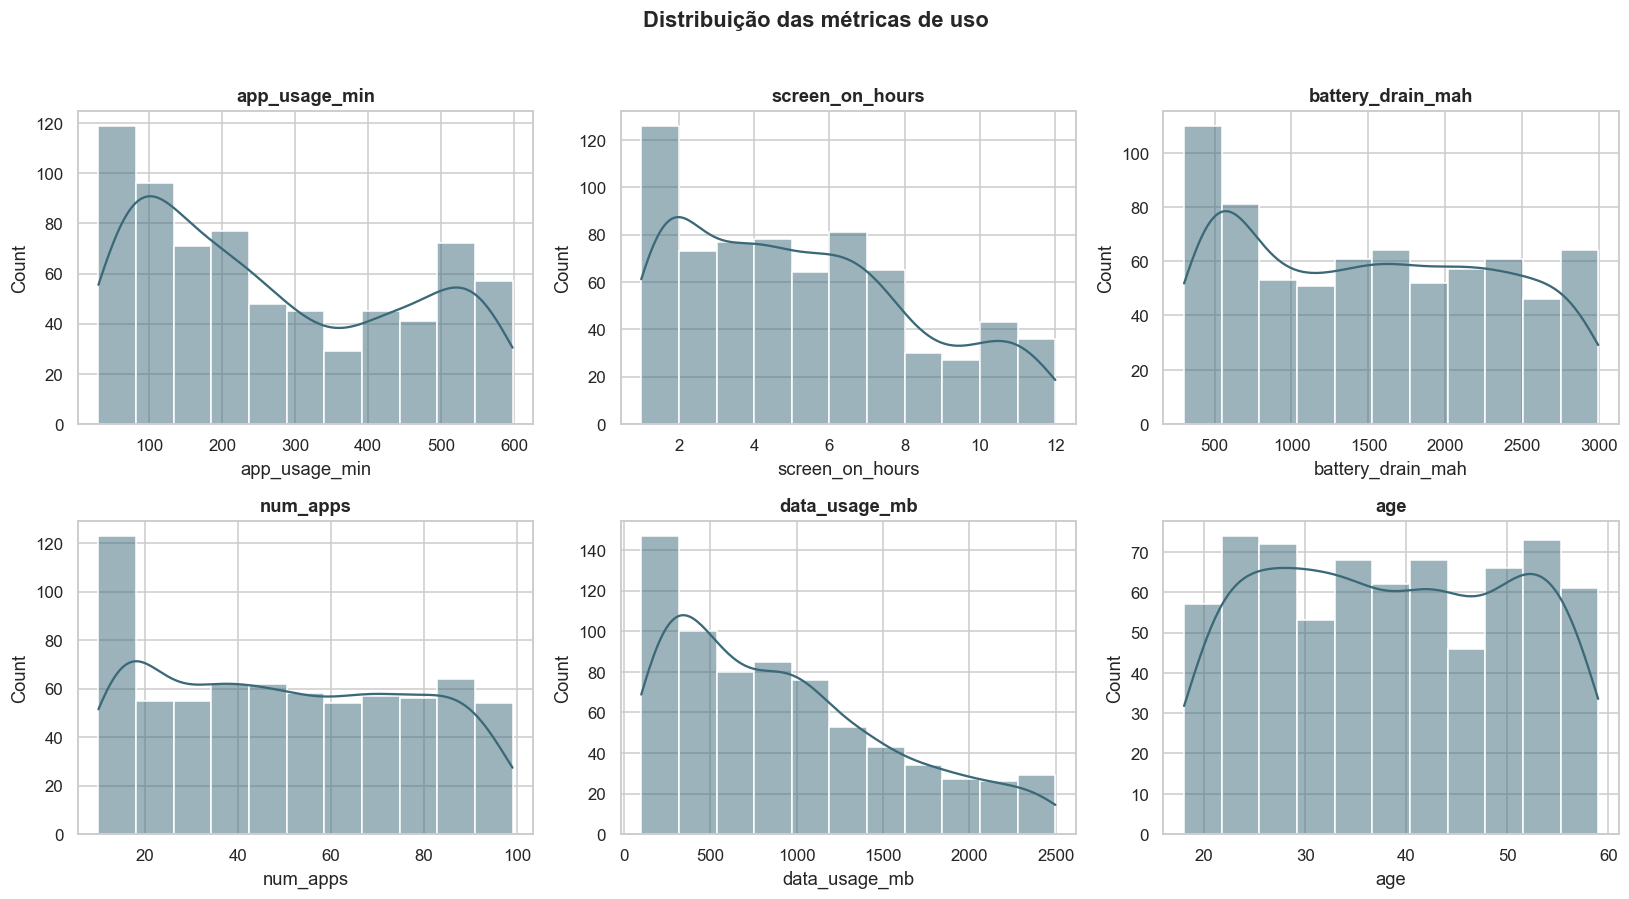

In [5]:
from src.visualization import plot_distribuicoes
_ = plot_distribuicoes(df)
plt.show()

## 3. EDA avançada
### 3.1 Outliers (IQR vs Z-score)

In [6]:
from src.eda_advanced import (resumo_outliers, matriz_correlacao,
                              analise_bivariada_alvo, perfil_por_classe, perfil_por_so)
resumo_outliers(df)

,outliers_iqr,outliers_iqr_%,outliers_zscore,outliers_zscore_%
variavel,,,,
app_usage_min,0,0.00,0,0.00
screen_on_hours,0,0.00,0,0.00
battery_drain_mah,0,0.00,0,0.00
num_apps,0,0.00,0,0.00
data_usage_mb,0,0.00,0,0.00
age,0,0.00,0,0.00


### 3.2 Correlação e associação com o perfil de uso
As métricas de uso são altamente correlacionadas entre si e com a classe de comportamento — a primeira pista de que o alvo é derivado delas.

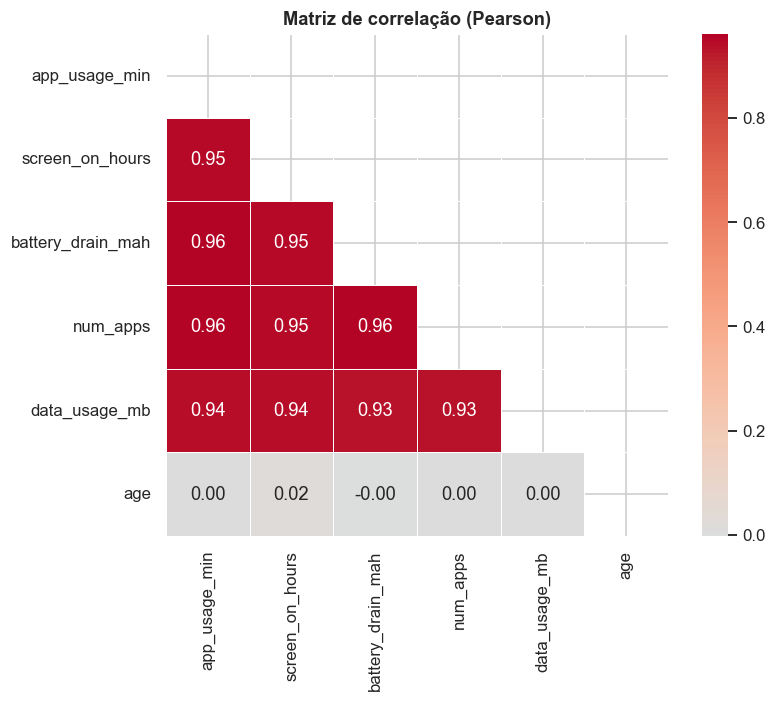

In [7]:
from src.visualization import plot_matriz_correlacao
_ = plot_matriz_correlacao(matriz_correlacao(df, 'pearson'), 'Matriz de correlação (Pearson)')
plt.show()

In [8]:
analise_bivariada_alvo(df)

,pearson_r,pearson_p,spearman_r,spearman_p
variavel,,,,
app_usage_min,0.97,0.00,0.98,0.00
num_apps,0.98,0.00,0.98,0.00
battery_drain_mah,0.98,0.00,0.98,0.00
data_usage_mb,0.95,0.00,0.98,0.00
screen_on_hours,0.96,0.00,0.98,0.00
age,-0.00,0.99,-0.00,0.95


,app_usage_min,screen_on_hours,battery_drain_mah,num_apps,data_usage_mb,age
behavior_label,,,,,,
1 - Muito leve,60.40,1.50,455.00,14.60,202.30,38.20
2 - Leve,132.00,3.00,883.80,30.80,451.40,38.60
3 - Moderado,235.40,5.00,"1,515.10",50.00,822.00,38.70
4 - Pesado,395.70,6.90,"2,105.80",69.90,"1,232.20",38.70
5 - Muito pesado,541.40,10.10,"2,701.00",89.20,"1,974.80",38.20


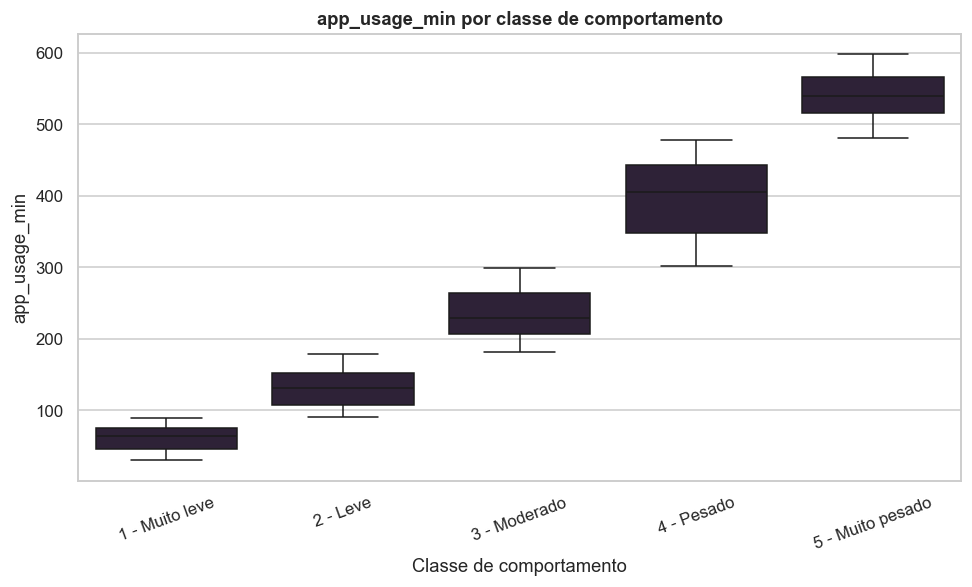

In [9]:
display(perfil_por_classe(df))
from src.visualization import plot_uso_por_classe
_ = plot_uso_por_classe(df, 'app_usage_min')
plt.show()

## 4. Estatística inferencial
### 4.1 Testes de hipótese
- Android vs iOS (teste t) · Gênero (teste t) · Classes (ANOVA) · SO × classe (qui-quadrado)

In [10]:
from src.inferential_stats import (teste_t_android_vs_ios, teste_t_genero,
                                   anova_classes, qui_quadrado, tabela_intervalos_confianca)
print(teste_t_android_vs_ios(df))
print(teste_t_genero(df))
print(anova_classes(df))
print(qui_quadrado(df))

[Teste t Android vs iOS (battery_drain_mah)] estatística=-1.0690, p-valor=0.2862 -> Sem diferença significativa (Android=1,508.2 vs iOS=1,589.5).
[Teste t por gênero (app_usage_min)] estatística=-0.1204, p-valor=0.9042 -> Sem diferença significativa entre gêneros (M=270.4 vs F=272.0).
[ANOVA por classe (app_usage_min)] estatística=4555.2992, p-valor=0 -> Ao menos uma classe difere em 'app_usage_min' (a métrica separa os perfis).
[Qui-quadrado (os x behavior_class)] estatística=2.4139, p-valor=0.6601 -> 'os' e 'behavior_class' são independentes.


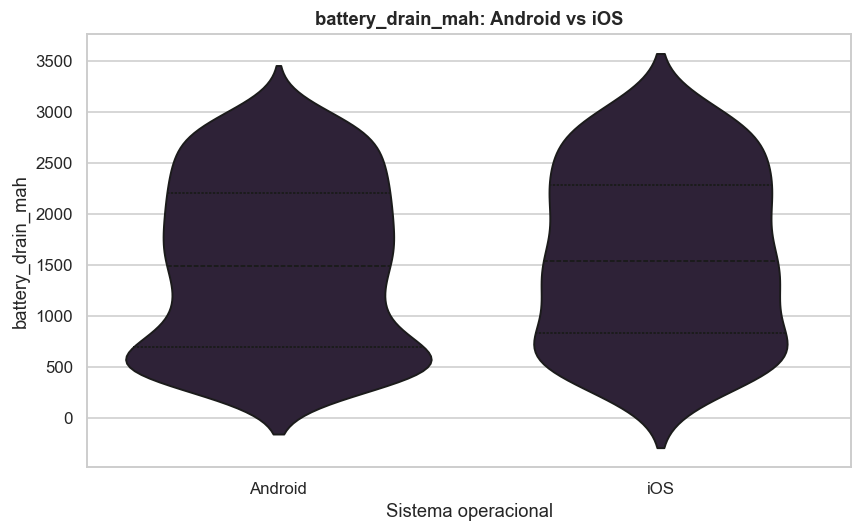

In [11]:
from src.visualization import plot_android_vs_ios
_ = plot_android_vs_ios(df, 'battery_drain_mah')
plt.show()

### 4.2 Intervalos de confiança (95%) — paramétrico vs bootstrap

In [12]:
tabela_intervalos_confianca(df)

,media,ic95_t_inferior,ic95_t_superior,ic95_boot_inferior,ic95_boot_superior
variavel,,,,,
app_usage_min,271.13,257.98,284.28,258.02,284.24
screen_on_hours,5.27,5.05,5.50,5.05,5.50
battery_drain_mah,"1,525.16","1,464.37","1,585.95","1,464.41","1,586.44"
num_apps,50.68,48.68,52.68,48.69,52.71
data_usage_mb,929.74,882.22,977.27,882.18,977.30
age,38.48,37.59,39.37,37.61,39.37


## 5. Modelagem
### 5.1 Regressão Linear — o que dirige o gasto de bateria

In [13]:
from src.modeling import treinar_regressao_linear, treinar_classificador, segmentar_kmeans
reg = treinar_regressao_linear(df)
print(f'R2 treino={reg.r2_treino:.3f} | teste={reg.r2_teste:.3f}\n')
reg.coeficientes.round(4)

R2 treino=0.946 | teste=0.944



,coeficiente,p_valor,ic_inferior,ic_superior
const,188.65,0.00,122.20,255.10
app_usage_min,1.38,0.00,1.00,1.77
screen_on_hours,55.80,0.00,35.26,76.35
num_apps,12.93,0.00,10.56,15.30
data_usage_mb,0.06,0.19,-0.03,0.15
age,-1.20,0.09,-2.58,0.18


### 5.2 Classificação — prever o perfil de uso
A acurácia perfeita (1,00) **não** é motivo de comemoração ingênua: revela que a `behavior_class` é uma função determinística das métricas (correlações ~0,98). Em produção, isso seria um alerta de *data leakage*.

In [14]:
clf = treinar_classificador(df)
print(f'Acurácia: {clf.acuracia:.3f}\n')
print(clf.relatorio)
print('Importância das variáveis:')
display(clf.importancias)

Acurácia: 1.000

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        34
           2       1.00      1.00      1.00        36
           3       1.00      1.00      1.00        36
           4       1.00      1.00      1.00        35
           5       1.00      1.00      1.00        34

    accuracy                           1.00       175
   macro avg       1.00      1.00      1.00       175
weighted avg       1.00      1.00      1.00       175

Importância das variáveis:


num_apps          2.52
app_usage_min     2.30
screen_on_hours   2.25
data_usage_mb     2.10
age               0.07
dtype: float64

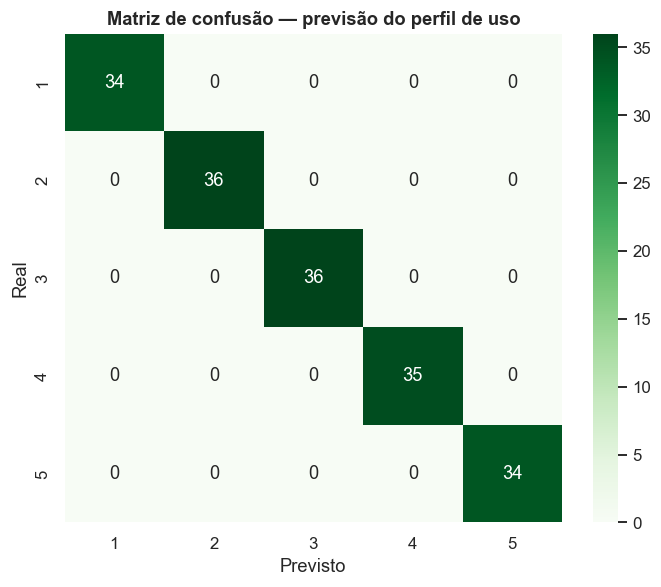

In [15]:
from src.visualization import plot_matriz_confusao
_ = plot_matriz_confusao(clf.matriz_confusao)
plt.show()

### 5.3 K-Means — segmentação não supervisionada
O *Adjusted Rand Index* mede o quanto os clusters concordam com as classes reais.

Silhouette=0.397 | Adjusted Rand Index=0.491



,n_usuarios,app_usage_min,screen_on_hours,num_apps,data_usage_mb,classe_real_media
cluster,,,,,,
0,147,321.80,6.00,60.20,"1,041.90",3.50
1,134,307.30,5.80,59.50,"1,008.00",3.50
2,136,541.40,10.10,89.20,"1,974.80",5.00
3,147,95.90,2.20,22.30,338.90,1.50
4,136,99.90,2.40,23.80,325.10,1.60


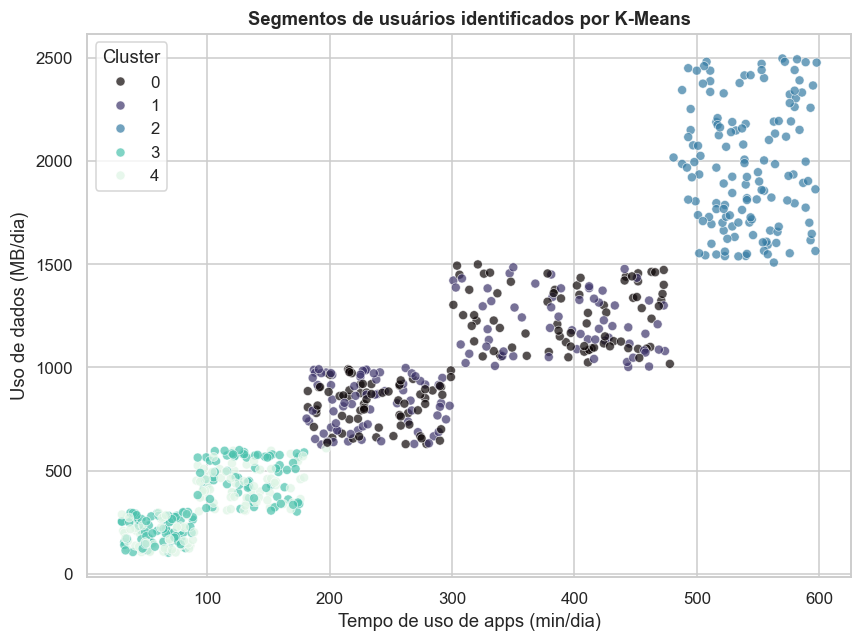

In [16]:
clu = segmentar_kmeans(df)
print(f'Silhouette={clu.silhouette:.3f} | Adjusted Rand Index={clu.rand_ajustado:.3f}\n')
display(clu.perfil_clusters)
from src.visualization import plot_clusters
_ = plot_clusters(clu.df_clusterizado)
plt.show()

## 6. Conclusões

- 🔋 O gasto de bateria é explicado quase inteiramente pelo uso (**R² = 0,94**): tempo de tela e nº de apps são os maiores drivers.
- 🤖🍏 **Android e iOS não diferem** significativamente; o SO é independente do perfil de uso.
- 🚻 **Gênero e idade não influenciam** o comportamento — o que importa é a intensidade.
- 🎯 As métricas **determinam** a classe de comportamento (acurácia 1,00) — um insight metodológico sobre a construção do alvo, não apenas um número alto.
- 🧩 O K-Means **recupera** os perfis de uso de forma não supervisionada.

> Pipeline completo: `python main.py` na raiz do projeto.